# ACLED Data

In [26]:
import pandas as pd
import numpy as np

# 1. Chargement des données ACLED
# Remplace par le bon chemin vers ton fichier
acled_path = '../data/raw/ACLED_data.xlsx'
df_acled = pd.read_excel(acled_path)

# 2. Filtrage pour le Nigeria uniquement
df_nga = df_acled[df_acled['COUNTRY'] == 'Nigeria'].copy()

# 3. Traitement des dates (Création de la colonne 'time' mensuelle)
# La colonne 'WEEK' contient la date de l'événement. On la ramène au 1er jour du mois
# pour correspondre exactement à la clé de ton dataset principal (YYYY-MM-01).
df_nga['date'] = pd.to_datetime(df_nga['WEEK'])
df_nga['time'] = df_nga['date'].dt.to_period('M').dt.to_timestamp()

# 4. Harmonisation des noms d'États (Admin1 -> NAME_1)
df_nga['NAME_1'] = df_nga['ADMIN1'].str.title()
# Attention : il faudra peut-être ajuster manuellement le nom d'Abuja 
# (parfois appelé "Abuja", "FCT" ou "Federal Capital Territory" selon les bases)
df_nga['NAME_1'] = df_nga['NAME_1'].replace({'Federal Capital Territory': 'Fct', 'Abuja': 'Fct'})

# 5. Filtrage des types de conflits pertinents pour la sécurité alimentaire
# Les manifestations pacifiques (Protests) impactent moins l'agriculture que la violence armée.
# On se concentre sur les événements destructeurs :
violent_events = ['Battles', 'Violence against civilians', 'Explosions/Remote violence']
df_nga_violent = df_nga[df_nga['EVENT_TYPE'].isin(violent_events)]

# 6. Agrégation par État et par Mois
conflict_monthly = df_nga_violent.groupby(['NAME_1', 'time']).agg(
    acled_events=('EVENTS', 'sum'),           # Nombre total d'attaques dans le mois
    acled_fatalities=('FATALITIES', 'sum')    # Nombre total de victimes
).reset_index()

# 7. Création de variables de stress cumulé (Rolling windows)
# Un conflit le mois dernier impacte la faim ce mois-ci. On crée des lags et des sommes cumulées.
conflict_monthly = conflict_monthly.sort_values(['NAME_1', 'time'])

# On crée une variable qui somme les conflits sur les 3 derniers mois (trimestre de violence)
conflict_monthly['acled_events_cum3'] = conflict_monthly.groupby('NAME_1')['acled_events'].rolling(window=3, min_periods=1).sum().reset_index(0, drop=True)
conflict_monthly['acled_fatalities_cum3'] = conflict_monthly.groupby('NAME_1')['acled_fatalities'].rolling(window=3, min_periods=1).sum().reset_index(0, drop=True)

# Lags (Le conflit d'il y a 1 mois)
conflict_monthly['acled_events_lag1'] = conflict_monthly.groupby('NAME_1')['acled_events'].shift(1)

print("Aperçu de la base ACLED agrégée :")
display(conflict_monthly.head())

Aperçu de la base ACLED agrégée :


,NAME_1,time,acled_events,acled_fatalities,acled_events_cum3,acled_fatalities_cum3,acled_events_lag1
0,Abia,2000-02-01,3,452,3.0,452.0,NaN
1,Abia,2000-05-01,1,2,4.0,454.0,3.0
2,Abia,2000-07-01,1,0,5.0,454.0,1.0
3,Abia,2002-08-01,1,0,3.0,2.0,1.0
4,Abia,2005-04-01,1,0,3.0,0.0,1.0


In [24]:
# 1. Charger ton fichier principal WFP
df_wfp = pd.read_csv('../data/processed/NIGERIA_WFP_ENGINEERED.csv')

# On s'assure que la colonne time est bien au format datetime pour le merge
df_wfp['time'] = pd.to_datetime(df_wfp['time'])

# Merge des deux dataframes
df_final = pd.merge(df_wfp, conflict_monthly, on=['NAME_1', 'time'], how='left')

# Si un Etat n'a pas de conflit un mois donne, le merge genere un NaN. On remplace par 0.
conflit_cols = ['acled_events', 'acled_fatalities', 'acled_events_cum3', 'acled_fatalities_cum3', 'acled_events_lag1']
df_final[conflit_cols] = df_final[conflit_cols].fillna(0)

# 5. Sauvegarde en ecrasant l'ancien fichier de modelisation
df_final.to_csv('NIGERIA_WFP_ENGINEERED.csv', index=False)

print(f"Merge reussi ! Dimensions du dataset mis a jour : {df_final.shape}")
display(df_final[['NAME_1', 'time', 'inadequate', 'acled_events', 'acled_events_lag1']].head(10))

KeyError: "None of [Index(['acled_events', 'acled_fatalities', 'acled_events_cum3',\n       'acled_fatalities_cum3', 'acled_events_lag1'],\n      dtype='object')] are in the [columns]"

## Addressing Omitted Variable Bias: ACLED Conflict Data Integration

### Context
During the exploratory data analysis (EDA), we identified a critical limitation in our model: the **omitted variable bias** caused by armed conflicts. In highly conflict-affected states (e.g., Borno, Zamfara), the immediate correlation between climate anomalies and food insecurity collapses. Conflict acts as a mediator—farmers cannot access their land or markets due to insecurity, which masks the true impact of climate shocks and artificially lowers the predictive power of our environmental variables.

### Methodology
To partial out this security channel and recover unbiased climate estimates, we integrated data from **ACLED** (Armed Conflict Location & Event Data Project). We filtered the dataset for Nigeria and isolated strictly violent, disruptive events (Battles, Violence against civilians, Explosions/Remote violence), aggregating them at the Admin-1 (State) and monthly level to match our panel structure.

### New Variables Engineered:
* **`acled_events`**: The total count of violent conflict events that occurred in a specific state during that exact month.
* **`acled_fatalities`**: The total number of reported fatalities from those violent events in that month.
* **`acled_events_lag1`**: The number of violent events in the *previous month* ($t-1$). This captures the immediate shock: a conflict last month prevents harvesting or disrupts supply chains, impacting food availability this month.
* **`acled_fatalities_cum3`**: The cumulative number of fatalities over the *last 3 months*. This acts as a proxy for prolonged, severe distress and systemic market destruction.

**Next Step:** By injecting `acled_events_lag1` and `acled_fatalities_cum3` into our Lasso and XGBoost models, we allow the algorithm to explicitly control for insecurity. This should "clean" the residual variance and restore the true explanatory power of our climate features (`WSI`, `is_lean_season`, etc.) in Northern states.

# Exploration

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique pour les graphiques
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14})

# Chargement de la base issue du merge précédent
df = pd.read_csv('../data/processed/NIGERIA_WFP_ENGINEERED.csv') 
df['time'] = pd.to_datetime(df['time'])

print(f"Dataset chargé : {df.shape[0]} observations, {df.shape[1]} variables.")

Dataset chargé : 1080 observations, 85 variables.


Pourcentage de mois sans aucun événement violent : 12.4%
Nombre d'États classés comme 'Haute Intensité' (>10 événements) : 29 / 30


C:\Users\valen\AppData\Local\Temp\ipykernel_31944\1640532123.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


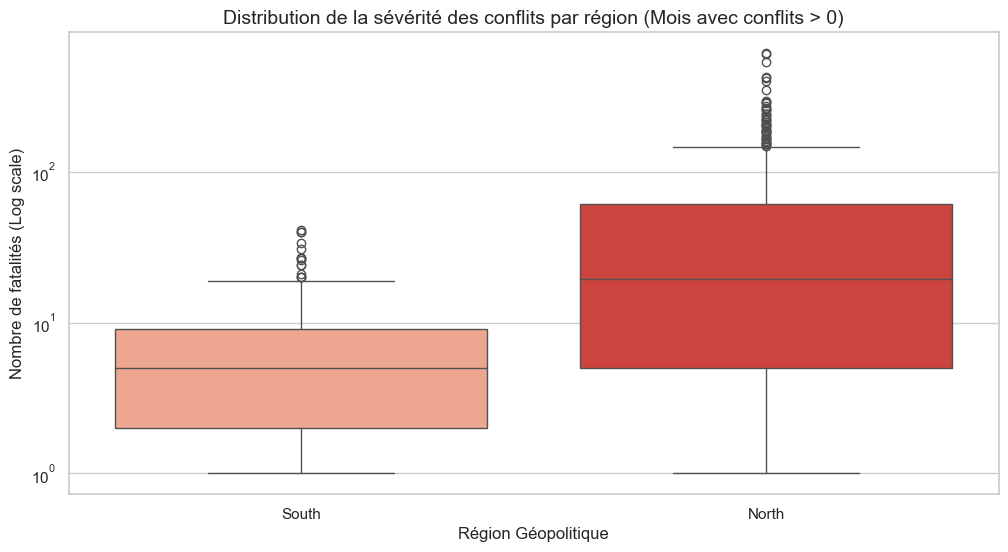

In [28]:
# 1. Calcul du taux de zéros (Sparsity)
zero_events_pct = (df['acled_events'] == 0).mean() * 100
print(f"Pourcentage de mois sans aucun événement violent : {zero_events_pct:.1f}%")

# 2. Création d'un flag binaire "Zone de conflit" 
# (ex: Un État est considéré comme zone de conflit s'il a eu plus de X événements au total)
total_events_by_state = df.groupby('NAME_1')['acled_events'].sum()
conflict_states = total_events_by_state[total_events_by_state > 10].index.tolist()
df['is_high_conflict_state'] = df['NAME_1'].apply(lambda x: 1 if x in conflict_states else 0)

print(f"Nombre d'États classés comme 'Haute Intensité' (>10 événements) : {len(conflict_states)} / {df['NAME_1'].nunique()}")

# 3. Visualisation : Fatalités par région géopolitique
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df[df['acled_fatalities'] > 0], # On ne plot que les mois avec au moins 1 mort pour voir la sévérité
    x='geopolitical_region', 
    y='acled_fatalities',
    palette='Reds'
)
plt.yscale('log') # Echelle log car les fatalités sont très asymétriques
plt.title("Distribution de la sévérité des conflits par région (Mois avec conflits > 0)")
plt.ylabel("Nombre de fatalités (Log scale)")
plt.xlabel("Région Géopolitique")
plt.show()

In [29]:
df['delta_inadequate'] = df.groupby('NAME_1')['inadequate'].diff()

In [30]:
df[['inadequate', 'delta_inadequate']].isna().sum()

inadequate          107
delta_inadequate    165
dtype: int64

In [ ]:
df.describe()

,time,inadequate,bnds,Y,X,Evap_tavg,LWdown_f_tavg,Lwnet_tavg,Psurf_f_tavg,Qair_f_tavg,...,FPAR_Lag_3,FPAR_Lag_4,FPAR_Lag_5,FPAR_Lag_6,acled_events,acled_fatalities,acled_events_cum3,acled_fatalities_cum3,acled_events_lag1,delta_inadequate
count,1080,973.000000,973.0,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,...,945.000000,916.000000,888.000000,859.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,915.000000
mean,2024-06-16 02:40:00,0.460512,0.5,9.103673,7.880080,0.000030,385.506084,-71.123840,97678.506005,0.012962,...,-0.255228,-0.241997,-0.226806,-0.213761,10.249074,26.967593,30.415741,81.189815,10.196296,0.000393
min,2023-01-01 00:00:00,0.000000,0.5,4.823889,3.404242,0.000002,288.491939,-145.817410,92665.337706,0.002679,...,-2.368000,-2.368000,-2.368000,-2.368000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.481992
25%,2023-09-23 12:00:00,0.331169,0.5,6.656335,5.999665,0.000012,367.422604,-103.776831,96488.499222,0.008290,...,-0.827333,-0.823167,-0.811875,-0.801833,2.000000,1.000000,8.000000,7.000000,2.000000,-0.040337
50%,2024-06-16 00:00:00,0.449664,0.5,9.332561,7.705265,0.000034,399.699266,-59.302236,97573.696091,0.015096,...,-0.280000,-0.271333,-0.257000,-0.245000,5.000000,5.000000,16.000000,19.000000,5.000000,0.000606
75%,2025-03-08 18:00:00,0.598684,0.5,11.821267,9.453793,0.000044,409.704869,-40.438801,99404.886522,0.017001,...,0.318000,0.325250,0.348250,0.355333,12.000000,21.000000,34.000000,73.750000,12.000000,0.045690
max,2025-12-01 00:00:00,1.000000,0.5,13.043215,13.153500,0.000067,430.240102,-30.334001,101273.345000,0.020087,...,1.978000,1.978000,1.978000,1.978000,107.000000,615.000000,261.000000,1582.000000,107.000000,0.509677
std,NaN,0.193396,0.0,2.529369,2.490551,0.000017,33.072199,33.714959,2049.353383,0.005034,...,0.759257,0.758353,0.753888,0.749396,14.595567,59.890817,40.609676,162.638908,14.487487,0.092172


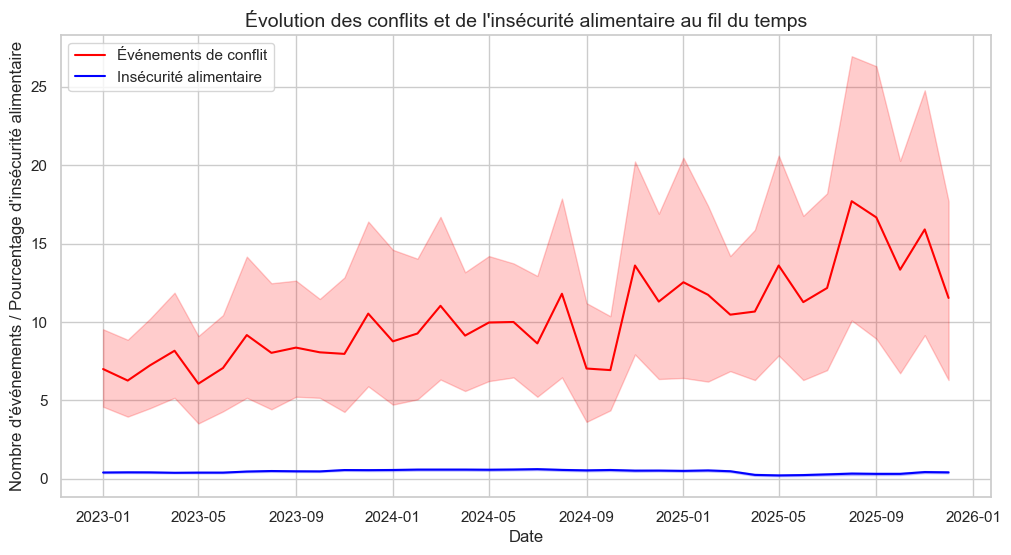

In [31]:
# 5. Evolution temporelle des conflits et de l'insécurité alimentaire
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='time', y='acled_events', label='Événements de conflit', color='red')
sns.lineplot(data=df, x='time', y='inadequate', label='Insécurité alimentaire', color='blue')
plt.title("Évolution des conflits et de l'insécurité alimentaire au fil du temps")
plt.xlabel("Date")
plt.ylabel("Nombre d'événements / Pourcentage d'insécurité alimentaire")
plt.legend()
plt.show()


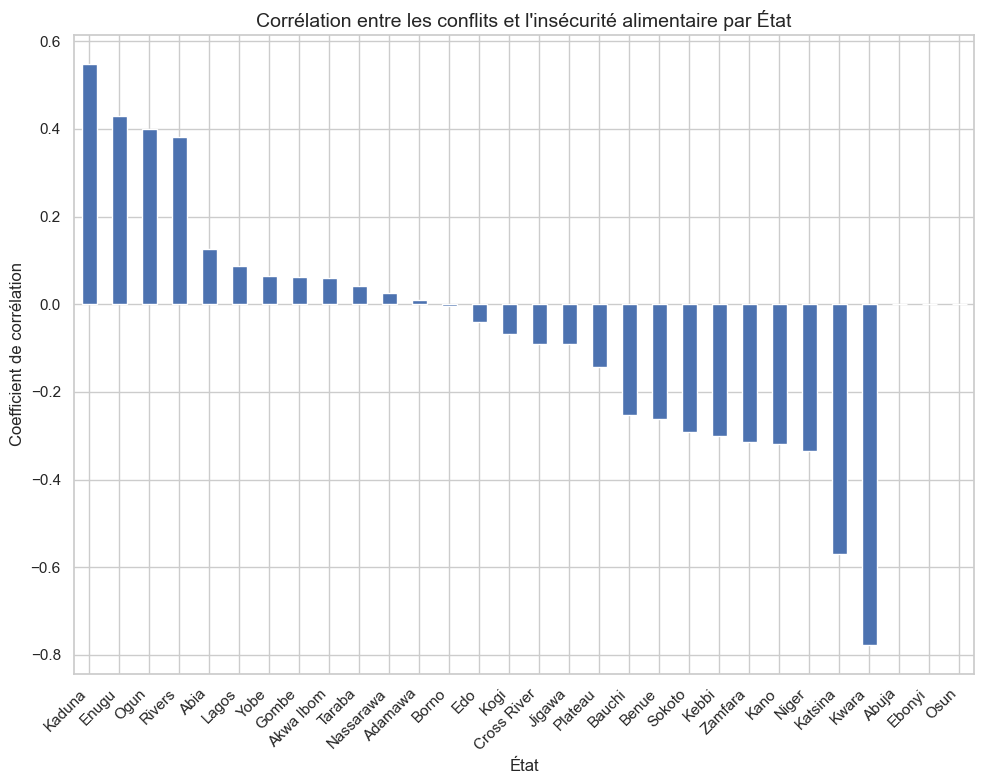

In [32]:

# 6. Corrélation entre les conflits et l'insécurité alimentaire par État
state_corr = df.groupby('NAME_1')[['acled_events', 'inadequate']].corr().unstack().iloc[:, 1]
state_corr = state_corr.sort_values(ascending=False)
plt.figure(figsize=(10, 8))
state_corr.plot(kind='bar')
plt.title("Corrélation entre les conflits et l'insécurité alimentaire par État")
plt.xlabel("État")
plt.ylabel("Coefficient de corrélation")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


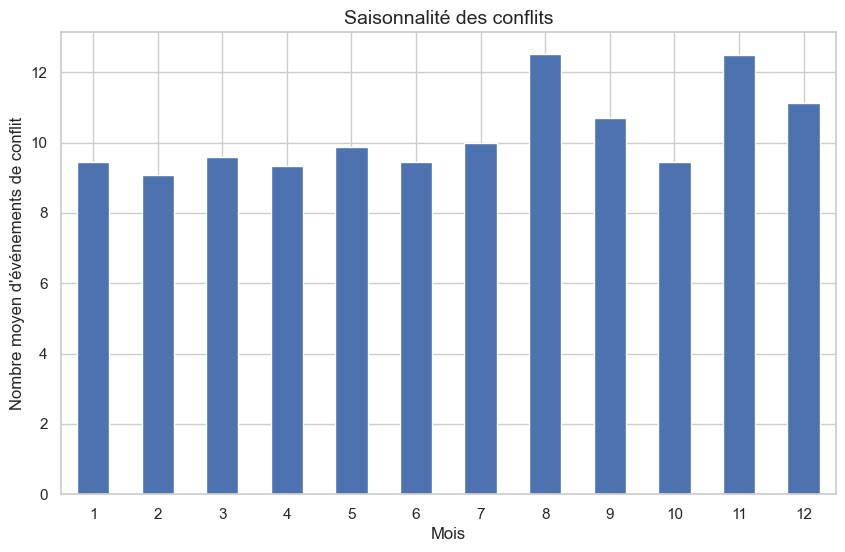

In [33]:

# 7. Analyse de la saisonnalité des conflits
df['month'] = df['time'].dt.month
seasonal_conflicts = df.groupby('month')['acled_events'].mean()
plt.figure(figsize=(10, 6))
seasonal_conflicts.plot(kind='bar')
plt.title("Saisonnalité des conflits")
plt.xlabel("Mois")
plt.ylabel("Nombre moyen d'événements de conflit")
plt.xticks(rotation=0)
plt.show()


Statistiques des conflits par État :
            acled_events                                acled_fatalities  \
                    mean median        std   min    max             mean   
NAME_1                                                                     
Abia            3.611111    2.5   3.297426   0.0   13.0         5.472222   
Abuja           0.000000    0.0   0.000000   0.0    0.0         0.000000   
Adamawa         3.611111    3.0   2.464349   0.0   11.0         5.805556   
Akwa Ibom       2.361111    2.0   1.987860   0.0    8.0         2.472222   
Bauchi          3.027778    2.0   2.813093   0.0   10.0         5.027778   
Benue          17.861111   15.0  10.642644   3.0   55.0        56.083333   
Borno          48.972222   45.5  17.938763  18.0  106.0       243.750000   
Cross River     2.250000    1.5   1.872737   0.0    6.0         3.000000   
Ebonyi          3.305556    3.0   2.447383   0.0   10.0         5.027778   
Edo             8.138889    6.5   6.076431   0.0   

C:\Users\valen\AppData\Local\Temp\ipykernel_31944\1450012099.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NAME_1', y='acled_events', palette='Reds')


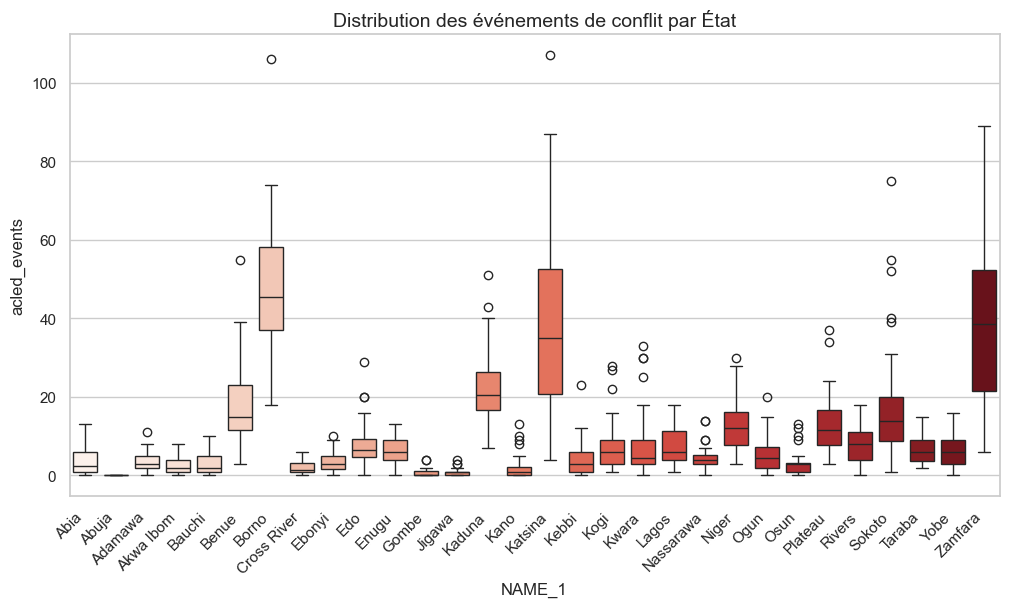

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr



# 1. Analyse de la distribution des conflits par État
conflict_stats = df.groupby('NAME_1')[['acled_events', 'acled_fatalities']].agg(['mean', 'median', 'std', 'min', 'max'])
print("Statistiques des conflits par État :")
print(conflict_stats)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='NAME_1', y='acled_events', palette='Reds')
plt.xticks(rotation=45, ha='right')
plt.title("Distribution des événements de conflit par État")
plt.show()

# Créer des catégories d'États selon le niveau de conflit
df['conflict_level'] = pd.cut(df['acled_events'], bins=[0, 10, 50, np.inf], labels=['low', 'medium', 'high'])


In [35]:
def analyze_optimal_lag(df, state_name, target_var='inadequate',
                        climate_var='WSI', max_lag=6, plot=False):
    col_state = 'NAME_1' if 'NAME_1' in df.columns else 'ADM1_NAME'
    df_state  = df[df[col_state] == state_name].sort_values('time').copy()
    if df_state.empty:
        return None

    lags, corrs = list(range(max_lag + 1)), []
    for lag in lags:
        col_name = climate_var if lag == 0 else f'{climate_var}_Lag_{lag}'
        if col_name in df_state.columns:
            valid = df_state[[target_var, col_name]].dropna()
            corrs.append(valid[target_var].corr(valid[col_name]) if len(valid) > 2 else 0)
        else:
            corrs.append(0)

    best_idx  = int(np.argmax([abs(c) for c in corrs]))
    best_lag  = lags[best_idx]
    best_corr = corrs[best_idx]

    if plot:
        fig, ax1 = plt.subplots(figsize=(12, 5))
        ax1.plot(df_state['time'], df_state[target_var],
                 color='tab:red', linewidth=2, label='Food Insecurity')
        ax1.set_ylabel('Inadequate Food Consumption (%)', color='tab:red')
        ax1.tick_params(axis='y', labelcolor='tab:red')
        ax2 = ax1.twinx()
        best_col = climate_var if best_lag == 0 else f'{climate_var}_Lag_{best_lag}'
        ax2.fill_between(df_state['time'], df_state[best_col],
                         color='tab:blue', alpha=0.25,
                         label=f'{climate_var} (Lag {best_lag})')
        ax2.set_ylabel(f'{climate_var} at Lag {best_lag}', color='tab:blue')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
        plt.title(f'{state_name}: {climate_var} (Lag {best_lag}) | r = {best_corr:.3f}')
        fig.tight_layout(); plt.show()

    return {'state': state_name, 'best_lag': best_lag, 'correlation': best_corr}

# ── Compute for all variables × states ────────────────────────────────────
climate_features = [
    'Evap_tavg', 'Rainf_f_tavg', 'Tair_f_tavg', 'Qair_f_tavg', 'Wind_f_tavg',
    'SoilMoi40_100cm_tavg', 'WSI', 'soil_anomaly', 'rain_anomaly', 'ndvi_anomaly'
]

lag_results = []
for var in climate_features:
    for state in df['NAME_1'].unique():
        res = analyze_optimal_lag(df, state, climate_var=var, plot=False)
        if res:
            res['variable'] = var
            lag_results.append(res)

df_all_lags = pd.DataFrame(lag_results)

top_drivers = (df_all_lags.groupby('variable')['correlation']
               .agg(lambda x: x.abs().mean())
               .sort_values(ascending=False))
print("=== Top Climate Drivers (mean |r| across all states) ===")
print(top_drivers.round(3).to_string())

best_row = df_all_lags.loc[df_all_lags['correlation'].abs().idxmax()]
print(f"\n→ Strongest signal: {best_row['state']} | {best_row['variable']} | "
      f"Lag {best_row['best_lag']} | r = {best_row['correlation']:.3f}")

# Créer les colonnes _opt en utilisant le meilleur décalage par état
all_climate_vars = [
    'Evap_tavg', 'Rainf_f_tavg', 'Tair_f_tavg', 'Qair_f_tavg', 'Wind_f_tavg',
    'SoilMoi40_100cm_tavg', 'WSI', 'soil_anomaly', 'rain_anomaly', 'ndvi_anomaly',
    'SPI_Cum1', 'SPI_Cum3', 'SPI_Cum6'
]

for var in all_climate_vars:
    if var not in df.columns:
        continue
    if var in df_all_lags['variable'].unique():
        best_lags_map = (df_all_lags[df_all_lags['variable'] == var]
                         .set_index('state')['best_lag'])
        def _get_opt(row, var=var, blm=best_lags_map):
            lag = int(blm.get(row['NAME_1'], 0))
            col = var if lag == 0 else f'{var}_Lag_{lag}'
            val = row.get(col, np.nan)
            if pd.isna(val):
                val = row.get(var, np.nan)  # fallback to lag=0
            return val
        df[f'{var}_opt'] = df.apply(_get_opt, axis=1)
    else:
        df[f'{var}_opt'] = df[var]  # no lag info: use current value

=== Top Climate Drivers (mean |r| across all states) ===
variable
WSI                     0.341
Tair_f_tavg             0.229
soil_anomaly            0.181
ndvi_anomaly            0.176
SoilMoi40_100cm_tavg    0.162
Wind_f_tavg             0.149
rain_anomaly            0.142
Rainf_f_tavg            0.128
Evap_tavg               0.111
Qair_f_tavg             0.108

→ Strongest signal: Adamawa | WSI | Lag 3 | r = 0.584


C:\Users\valen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\valen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
